# <u>Hyperparameter Tuning</u>

### Prerequisites:


* <a href="Supervised ML Basis.ipynb">Check out the notebook on Supervised ML Basis</a>

* <a href="../1.Supervised Learning/Evaluation.ipynb">Check out the notebook on Evaluation</a>


    
## Topics

* [1. What is Hyperparameter Tuning?](#what)
* [2. Why Tuning Matters](#matter)
* [3. Why Tuning is Hard](#hard)
    * [3.1 Huge search spaces](search)
    * [3.2 Black-box optimization problem](box)
    * [3.3 Mixed parameter types](#types)
* [4. Untouched Test Set Principle](#test)
* [5. Nested Resampling](#resampling)
* [6. Basic Tuning Techniques](#techniques)
    * [6.1 Grid Search](#grid)
    * [6.2 Random Search](#random)
* [7. Advanced Tuning Techniques](#advanced)
    * [7.1 Evolutionary Algorithms (EAs)](#evolution)
    * [7.2 Bayesian Optimization (BO)](#bayesian)
    * [7.3 Multi-Fidelity Optimization](#fidelity)
* [8. Pipelines in Machine Learning](#pipeline)
* [9. Pipelines as DAGs and AutoML](#DAGs)
* [10. Main Challenges of AutoML / HPO](#AutoML)

In [89]:
import numpy as np # for random numbers and arrays

# Plotting
import matplotlib.pyplot as plt # for plotting
import plotly.express as px # for plotting
import plotly.graph_objects as go # for plotting


# Create Datasets
from sklearn.datasets import make_regression # create toy data for Regression
from sklearn.datasets import make_classification # create toy data for Classification
from sklearn.datasets import make_blobs # create toy data also for Classification
from sklearn.datasets import make_moons # create toy data also for Classification

from sklearn.model_selection import train_test_split # split dataset into train and test set

# Metrics for Regression
from sklearn.metrics import (
    mean_squared_error, # MSE
    mean_absolute_error, # MAE
    mean_absolute_percentage_error, # MAPE
    r2_score # R^2
)

from sklearn.metrics import make_scorer # This is used when we want to create a custom evaluation metric for models 
                                        # (e.g., for cross-validation or grid search)

def my_metric(y_true, y_pred):
    return abs(y_true - y_pred).mean()

scorer = make_scorer(my_metric, greater_is_better=False) # make_scorer wraps it so sklearn can use it in GridSearchCV,cross_val_score etc.

# Metric for Classification
from sklearn.metrics import (
    accuracy_score, # Accuracy
    brier_score_loss, # Brier Score
    log_loss, # Log Loss
    confusion_matrix, # TP, FP, FN, TN
    precision_score, # Precision = PPV
    recall_score, # Recall = TPR
    roc_auc_score, # Area under ROC curve
    roc_curve, # ROC curve
)

# Common preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import OneHotEncoder


# Nested resampling
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score # runs cross-validation and returns just the scores per fold
from sklearn.model_selection import cross_validate # more advanced version of cross_val_score that returns multiple metrics and extra info
from sklearn.model_selection import cross_val_predict # Generates predictions for each data point using cross-validation

# Grid and Random Search
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

# Pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer # dataset has different types of features (e.g., numeric + categorical) and we
                                              # want to apply different preprocessing steps to different columns

# Bayesian Optimization (BO)
#from skopt import BayesSearchCV
#import optuna
#from optuna.integration import OptunaSearchCV
#from hyperopt import fmin, tpe, hp, Trials

# Evolutionary Algorithm
#from deap import base, creator, tools, algorithms
#from tpot import TPOTClassifier
#from tpot import TPOTRegressor
#import cma

# Successive Halving
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.model_selection import HalvingRandomSearchCV

# Hyperband
#from ray import tune
#from ray.tune.schedulers import HyperBandScheduler
#from ray.tune.schedulers import ASHAScheduler
#import keras_tuner as kt
#from optuna.pruners import HyperbandPruner

# Stochastic Local Searc
from scipy.optimize import dual_annealing
from scipy.optimize import basinhopping

# AutoML
#import autosklearn.classification
#import autosklearn.regression
#from tpot import TPOTClassifier
#from flaml import AutoML
#from h2o.automl import H2OAutoML



# ML algorithms
from sklearn.neighbors import KNeighborsClassifier # k neares neighbors
from sklearn.linear_model import LinearRegression # perform OLS
from sklearn.linear_model import Ridge # Ridge Regression
from sklearn.tree import DecisionTreeClassifier # for Classification trees
from sklearn.tree import DecisionTreeRegressor # for Regression trees
from sklearn.linear_model import Ridge # Ridge regression
from sklearn.svm import SVC # (non) linear (non)separable SVM
from sklearn.linear_model import LogisticRegression # logistic regression
from sklearn.naive_bayes import GaussianNB # Naive Bayes
from sklearn.ensemble import RandomForestClassifier # Random forest classifier

print("Setup complete")

Setup complete


<a class="anchor" id="what"></a>

# 1. What is Hyperparameter Tuning?

**A machine learning algorithm has two kinds of quantities:**
- Model parameters $\theta$: Learned automatically during training and are output of training (e.g. regression coefficients, tree split points)
- Hyperparameters $\lambda$: Input of training set before training the model and control how learning happens (e.g. tree depth, number of neighbors in k-NN, learning rate, number of trees)

**The process of finding a good hyperparameter configuration is called hyperparameter tuning or <u>hyperparameter optimization (HPO)</u>.**

### Core idea:
Hyperparameters determine model complexity and training behavior, so a poor choice can lead to:
- underfitting (model too simple)
- overfitting (model too complex)

Good tuning seeks the configuration that gives the best generalization performance on unseen data.

**Examples of Hyperparameters:**
- Maximum deoth of a Decision Tree
- Number of Trees of a Random Forest
- Minimal number of observations per leaf and splitting criterion (gini impurity, MCE)
- k in k-NN as well as the distance measure (euclidean or manhattan)
- Regularization strenght $\lambda$ in Ridge and Lasso Regression
- Polynomial degree $d$ in Polynomial Regression
- Number and maximal order of interactions for Multiple linear Regression
 

<a class="anchor" id="matter"></a>
# 2. Why Tuning Matters

**Even strong algorithms can perform badly if hyperparameters are poorly chosen.**

Example: A classification tree with depth = 4 may be
- too shallow for complex data, or
- too deep for simple data.

So we must systematically test several values and compare predictive performance.


**Goal:Find the hyperparameter vector $\lambda^*$ that minimizes estimated generalization error.**


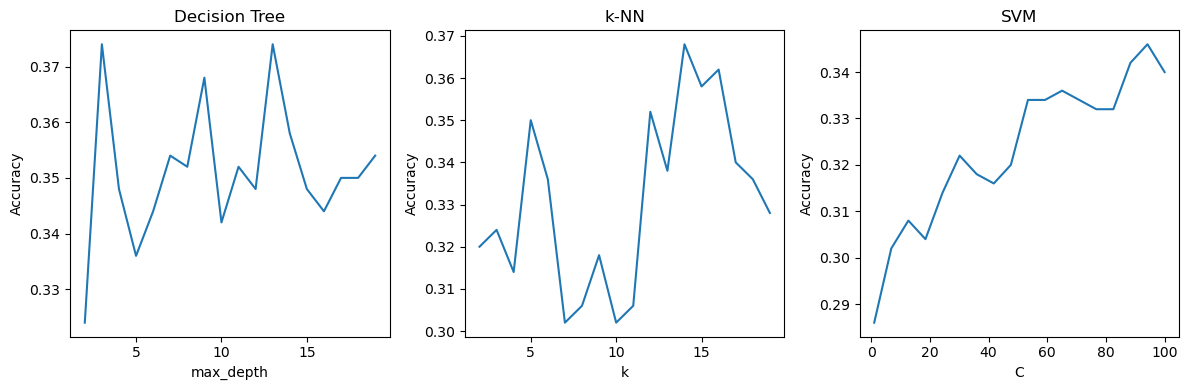

In [39]:
n = 500
X, y = make_classification(n_samples=500,n_features=10,n_informative=5,n_redundant=2,n_classes=3,class_sep=2.0,flip_y=0.1,random_state=1931)
y = np.random.permutation(y) # slight label noise 

max_depths = np.arange(2, 20)
neighbors = np.arange(2, 20)
C_vals = np.linspace(1, 100, len(neighbors))

k_fold = KFold(n_splits=4, shuffle=True, random_state=1955)

ml_models_errors = {"Classification Tree": [],"k-Neares Neighbors": [],"SVM": []}

for max_depth, k, C in zip(max_depths, neighbors, C_vals):
    
    ml_models = {
        "Classification Tree": DecisionTreeClassifier(max_depth=max_depth, random_state=1847),
        "k-Neares Neighbors": KNeighborsClassifier(n_neighbors=k),
        "SVM": SVC(C=C)}

    for name, model in ml_models.items():
        accs = [] 

        for train_idx, test_idx in k_fold.split(X):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            model.fit(X_train, y_train)
            y_preds = model.predict(X_test)
            accs.append(accuracy_score(y_test, y_preds))

        ge_estimate = np.mean(accs)  # single value
        ml_models_errors[name].append(ge_estimate)


# Plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(max_depths, ml_models_errors["Classification Tree"])
plt.title("Decision Tree")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")

plt.subplot(1, 3, 2)
plt.plot(neighbors, ml_models_errors["k-Neares Neighbors"])
plt.title("k-NN")
plt.xlabel("k")
plt.ylabel("Accuracy")

plt.subplot(1, 3, 3)
plt.plot(C_vals, ml_models_errors["SVM"])
plt.title("SVM")
plt.xlabel("C")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

<a class="anchor" id="hard"></a>
# 3. Why Tuning is Hard

**Hyperparameter optimization is challenging for multiple reasons.**

<a class="anchor" id="search"></a>
## 3.1 Huge search spaces

If several hyperparameters each have many possible values, the number of combinations grows exponentially.

Hyperparameter search space $\Lambda$ grows exponentially.

<a class="anchor" id="box"></a>
## 3.2 Black-box optimization problem

We cannot directly compute how good a hyperparameter setting $\lambda \in \Lambda$ is (no gradients,only evaluation).

To evaluate one configuration, we must:

1. train the model,
2. validate/test it,
3. compute a performance metric.

So each evaluation is expensive.

<a class="anchor" id="types"></a>
## 3.3 Mixed parameter types

Summarize all Hyperparameters in a vector $\lambda \in \Lambda$ with possibly mixed types:

- continuous
    - e.g. minimal error improvement in a tree to accept a split
- integer
    - e.g. Neighborhood size k in k-NN
    - e.g. number of base learners (trees) in Random Forests
- categorical
    - e.g. Split criterion for Classification Trees
    - e.g. Distance measure for k-NN
- hierarchical/dependent
    - e.g. Tree depth depends on minimal leaf size we allow

This makes standard calculus-based optimization unusable.

<a class="anchor" id="test"></a>
# 4. Untouched Test Set Principle

**We must not use the same data both to tune hyperparameters and to estimate final performance.**

Otherwise performance estimates of $\widehat{\text{GE}}$ become optimistically biased.

Correct approach:

- use training/validation data to tune,
- keep a final test set untouched until the very end

<p align="center">
<img src="pics/38.png" width="600"/>
</p>

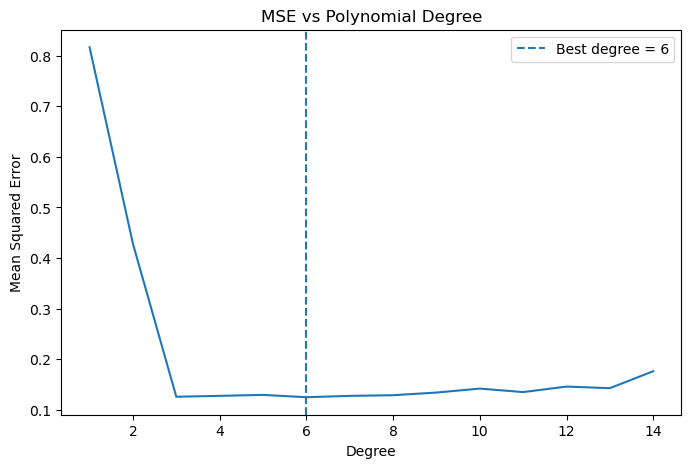

Generalization estimate: 0.080


In [59]:
n = 200
rng = np.random.RandomState(2001)

X = 2 * rng.rand(n, 1) - 1   # values in [-1, 1]
y = 3 * X.squeeze()**3 - 2 * X.squeeze()**2 + X.squeeze() + rng.normal(0, 0.3, n)

# Hold-out test set
X_train_full, X_test_untouched, y_train_full, y_test_untouched = train_test_split(X, y, random_state=2001)

degrees = np.arange(1, 15)
kfold = KFold(n_splits=5, shuffle=True, random_state=2010)

mses = []

for d in degrees:
    mse_fold = []

    for train_idx, val_idx in kfold.split(X_train_full):
        X_train = X_train_full[train_idx]
        X_valid = X_train_full[val_idx]
        y_train = y_train_full[train_idx]
        y_valid = y_train_full[val_idx]

        # Polynomial transform
        poly = PolynomialFeatures(degree=d)
        X_train_poly = poly.fit_transform(X_train)
        X_valid_poly = poly.transform(X_valid) # do not write fit_transform since validation data needs to be unseen (no data leakage)

        model = LinearRegression()
        model.fit(X_train_poly, y_train)

        y_preds = model.predict(X_valid_poly)
        mse_fold.append(mean_squared_error(y_valid, y_preds))

    mses.append(np.mean(mse_fold))

# -Plot 
plt.figure(figsize=(8,5))
plt.plot(degrees, mses)

best_degree = degrees[np.argmin(mses)]
plt.axvline(best_degree, linestyle='--', label=f"Best degree = {best_degree}")

plt.title("MSE vs Polynomial Degree")
plt.xlabel("Degree")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.show()

# Now train train and validation set and test on untouched test set with best hyperparameter to get Generalization error estimate
poly = PolynomialFeatures(degree=best_degree)
poly.fit(X_train_full)
X_train_full_poly = poly.transform(X_train_full)
model = LinearRegression().fit(X_train_full_poly,y_train_full)
X_test_untouched_poly = poly.transform(X_test_untouched)
preds = model.predict(X_test_untouched_poly)
GE = mean_squared_error(y_test_untouched,preds)
print(f"Generalization estimate: {GE:.3f}")


<a class="anchor" id="resampling"></a>
# 5. Nested Resampling

To get a robust and unbiased estimate $\widehat{\text{GE}}$ with low variance, perfrom nested resampling:

Outer loop (performance estimations): 

- k-fold CV gives multiple test sets
- Averaging across folds reduces variance of the $\text{GE}$ estimate

Inner loop (hyperparameter tuning):

- For each outer training set inner m-fold CV is used to select the best $\lambda \in \Lambda$ denoted as $\lambda^*$

Instead of relying on a single split we average across many train/validation/test splits which reduces variance of estimates $\widehat{\text{GE}}$ of  $\text{GE}$

$\Rightarrow$ This mimics the untouched-test-set principle while reducing variance compared with one single holdout split.


<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/39.png" width="550"/>
  <img src="pics/47.jpg" width="550"/>
</div>

In [67]:
X, y = make_classification(n_samples=200,n_features=5,n_informative=3,n_redundant=0,n_classes=2,random_state=2035)

# Hyperparameters
k_values = np.arange(1, 31)

# Outer CV (performance estimation)
outer_kfold = KFold(n_splits=5, shuffle=True, random_state=1) # 5-fold outer CV

outer_scores = []

for outer_train_idx, outer_test_idx in outer_kfold.split(X):

    X_outer_train = X[outer_train_idx]
    X_outer_test = X[outer_test_idx]
    y_outer_train = y[outer_train_idx]
    y_outer_test = y[outer_test_idx]

    # Inner CV (hyperparameter tuning)
    inner_kfold = KFold(n_splits=4, shuffle=True, random_state=2)

    k_scores = []

    for k in k_values:
        inner_accuracies = []

        for inner_train_idx, inner_val_idx in inner_kfold.split(X_outer_train):

            X_inner_train = X_outer_train[inner_train_idx]
            X_inner_val = X_outer_train[inner_val_idx]
            y_inner_train = y_outer_train[inner_train_idx]
            y_inner_val = y_outer_train[inner_val_idx]

            model = KNeighborsClassifier(n_neighbors=k)
            model.fit(X_inner_train, y_inner_train)

            y_pred = model.predict(X_inner_val)
            inner_accuracies.append(accuracy_score(y_inner_val, y_pred))

        k_scores.append(np.mean(inner_accuracies))

    # Best k from inner loop
    best_k = k_values[np.argmax(k_scores)]
    print("Best k:", best_k)

    # Train final model on full outer training set
    final_model = KNeighborsClassifier(n_neighbors=best_k)
    final_model.fit(X_outer_train, y_outer_train)

    # Evaluate on outer test set
    y_test_pred = final_model.predict(X_outer_test)
    outer_scores.append(accuracy_score(y_outer_test, y_test_pred))

print(f"Estimated Generalization error: {np.mean(outer_scores):.3f}")
print(f"Std of estimate: {np.std(outer_scores):.3f}")

Best k: 12
Best k: 3
Best k: 28
Best k: 12
Best k: 6
Estimated Generalization error: 0.895
Std of estimate: 0.043


<a class="anchor" id="techniques"></a>
# 6. Basic Tuning Techniques


<a class="anchor" id="grid"></a>
## 6.1 Grid Search

**Choose a finite list of candidate values for each hyperparameter and test all combinations.**

Advantages
- simple
- works for all parameter types
- easy to parallelize

Disadvantages
- combinatorial explosion
- inefficient because many irrelevant regions are tested
- requires arbitrary discretization choices

<p align="center">
<img src="pics/40.png" width="600"/>
</p>

```python
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error')
```

Best params: (np.int64(20), np.int64(4))
Best params: (np.int64(17), np.int64(4))
Best params: (np.int64(12), np.int64(3))

Estimated Generalization Accuracy: 0.8950701040253279
Std: 0.011636979041400814


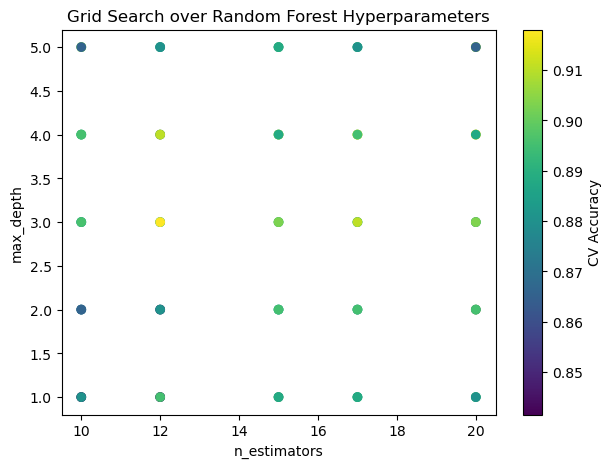

In [77]:
X, y = make_classification(n_samples=200,n_features=5,n_informative=3,n_redundant=0,n_classes=2,random_state=2035)

# Hyperparameter Grid
n_estimators_grid = np.linspace(10, 20, 5, dtype=int)
max_depth_grid = np.arange(1, 6)

# Outer CV
outer_kfold = KFold(n_splits=3, shuffle=True, random_state=1)

outer_scores = []

# store all grid results for plotting
grid_results = []

for outer_train_idx, outer_test_idx in outer_kfold.split(X):

    X_outer_train, X_outer_test = X[outer_train_idx], X[outer_test_idx]
    y_outer_train, y_outer_test = y[outer_train_idx], y[outer_test_idx]

    # Inner CV (Grid Search)
    inner_kfold = KFold(n_splits=3, shuffle=True, random_state=2)

    best_score = -np.inf
    best_params = None

    for n_est in n_estimators_grid:
        for depth in max_depth_grid:

            inner_scores = []

            for tr_idx, val_idx in inner_kfold.split(X_outer_train):

                X_tr, X_val = X_outer_train[tr_idx], X_outer_train[val_idx]
                y_tr, y_val = y_outer_train[tr_idx], y_outer_train[val_idx]

                model = RandomForestClassifier(n_estimators=n_est,max_depth=depth,random_state=2136,n_jobs=1)

                model.fit(X_tr, y_tr)
                preds = model.predict(X_val)

                inner_scores.append(accuracy_score(y_val, preds))

            mean_score = np.mean(inner_scores)

            # store for visualization (outer fold dependent)
            grid_results.append((n_est, depth, mean_score))

            if mean_score > best_score:
                best_score = mean_score
                best_params = (n_est, depth)

    best_n_est, best_depth = best_params
    print("Best params:", best_params)

    # Final Model on Outer Train
    final_model = RandomForestClassifier(n_estimators=best_n_est,max_depth=best_depth,random_state=2136)

    final_model.fit(X_outer_train, y_outer_train)
    preds = final_model.predict(X_outer_test)

    outer_scores.append(accuracy_score(y_outer_test, preds))


grid_results = np.array(grid_results)

print("\nEstimated Generalization Accuracy:",
      np.mean(outer_scores))
print("Std:", np.std(outer_scores))


plt.figure(figsize=(7,5))

plt.scatter(grid_results[:, 0],grid_results[:, 1],c=grid_results[:, 2],cmap="viridis")

plt.xlabel("n_estimators")
plt.ylabel("max_depth")
plt.title("Grid Search over Random Forest Hyperparameters")
plt.colorbar(label="CV Accuracy")

plt.show()

<a class="anchor" id="random"></a>
## 6.2 Random Search

**Instead of exhaustively testing a grid, sample configurations randomly (uniformly).**

Advantages
- simple
- can stop anytime
- often explores important dimensions better than grid search

Disadvantages
- still inefficient in high dimensions
- may waste trials in poor regions

Important takeaway:

&nbsp; Random search often better because not all hyperparameters matter equally.

<p align="center">
<img src="pics/41.png" width="600"/>
</p>

```python
from sklearn.model_selection import RandomizedSearchCV
rand = RandomizedSearchCV(model, param_distributions, n_iter=50, cv=5)
```

Best params: (np.int64(20), np.int64(4))
Best params: (np.int64(17), np.int64(4))
Best params: (np.int64(20), np.int64(3))

Estimated Generalization Accuracy: 0.8950701040253279
Std: 0.011636979041400814


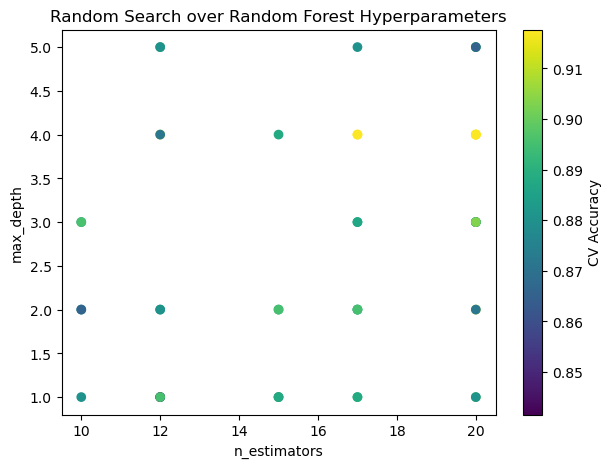

In [78]:
X, y = make_classification(n_samples=200,n_features=5,n_informative=3,n_redundant=0,n_classes=2,random_state=2035)

# Hyperparameter ranges
n_estimators_grid = np.linspace(10, 20, 5, dtype=int)
max_depth_grid = np.arange(1, 6)

# Random search settings
n_random_samples = 15  

# Outer CV
outer_kfold = KFold(n_splits=3, shuffle=True, random_state=1)

outer_scores = []
grid_results = []

for outer_train_idx, outer_test_idx in outer_kfold.split(X):

    X_outer_train, X_outer_test = X[outer_train_idx], X[outer_test_idx]
    y_outer_train, y_outer_test = y[outer_train_idx], y[outer_test_idx]

    inner_kfold = KFold(n_splits=3, shuffle=True, random_state=2)

    best_score = -np.inf
    best_params = None

    # Random Search (instead of full grid)
    for _ in range(n_random_samples):

        n_est = np.random.choice(n_estimators_grid)
        depth = np.random.choice(max_depth_grid)

        inner_scores = []

        for tr_idx, val_idx in inner_kfold.split(X_outer_train):

            X_tr, X_val = X_outer_train[tr_idx], X_outer_train[val_idx]
            y_tr, y_val = y_outer_train[tr_idx], y_outer_train[val_idx]

            model = RandomForestClassifier(n_estimators=n_est,max_depth=depth,random_state=2136,n_jobs=1)

            model.fit(X_tr, y_tr)
            preds = model.predict(X_val)

            inner_scores.append(accuracy_score(y_val, preds))

        mean_score = np.mean(inner_scores)

        # store for visualization
        grid_results.append((n_est, depth, mean_score))

        if mean_score > best_score:
            best_score = mean_score
            best_params = (n_est, depth)

    best_n_est, best_depth = best_params
    print("Best params:", best_params)

    # Final model
    final_model = RandomForestClassifier(n_estimators=best_n_est,max_depth=best_depth,random_state=2136)

    final_model.fit(X_outer_train, y_outer_train)
    preds = final_model.predict(X_outer_test)

    outer_scores.append(accuracy_score(y_outer_test, preds))


grid_results = np.array(grid_results)

print("\nEstimated Generalization Accuracy:",
      np.mean(outer_scores))
print("Std:", np.std(outer_scores))


plt.figure(figsize=(7,5))

plt.scatter(grid_results[:, 0],grid_results[:, 1],c=grid_results[:, 2],cmap="viridis")

plt.xlabel("n_estimators")
plt.ylabel("max_depth")
plt.title("Random Search over Random Forest Hyperparameters")
plt.colorbar(label="CV Accuracy")

plt.show()

<a class="anchor" id="advanced"></a>
# 7. Advanced Tuning Techniques

<a class="anchor" id="evolution"></a>
## 7.1 Evolutionary Algorithms (EAs)

**Idea:** EAs stochastic, population based optimization algorithm. Instead of optimizing one Hyperparameter configuration (HPC) at a time, they maintain a population of candidate solutions and improve them over generations using evolutionary principles.

**How it works in HPO:**
1. Initialization: Start with random population of HPC $\lambda^{(1)},\lambda^{(2)},\ldots,\lambda^{(\text{pop})}$
2. Selecttion: Choose best-performing candidates (parents) to "survive"
    - Common strategies: Roulette wheel, uniform selection
3. Crossover: Combine parts of two parents to form a new candidate
    - e.g. Parent A: max_depth = 5,Parent B: max_depth = 10 $\Rightarrow$ Child: max_depth = 7
4. Mutation: Randomly change some Hyper parameters (HP) of a candidate
5. Evaluation: Measure performance (e.g. accuracy, AUV,log loss) of each HPC
6. Selection: Insert new offspring into the population, possibly replacing the worst candidate


EAs is useful because they do not need gradients and can search complex spaces.

<p align="center">
<img src="pics/42.png" width="600"/>
</p>

In [ ]:
#from deap import base, creator, tools, algorithms
#from tpot import TPOTClassifier
#from tpot import TPOTRegressor
#import cma

<a class="anchor" id="bayesian"></a>
## 7.2 Bayesian Optimization (BO)

BO treats HPO as a black-box function optimization problem:
$$
f(\lambda) = \widehat{\text{GE}}(\mathcal{I},\mathcal{J},\rho,\lambda)
$$
- $\mathcal{I}$ is the learner/inducer which takes data as input and searches through possible machine learning models and finds the model that fits the data best according to some risk measure $\rho$
- $\mathcal{J}$ is the resampling splits

Problem: $f$ is expensive to evaluate (requires training & validation)
Solution: BO builds a cheap surrogate model of $f$ and uses it to giude which HPC to try

**How it works:**
1. Surrogate model: Approximate relationship between HP $\lambda$ and performance $c(\lambda)$
  - Often Gaussian Process (GPs) for continuous parameters
  - Surrogate provides mean prediction $\hat{c}(\lambda)$ and uncertainty estimate $\hat{\sigma}(\lambda)$ 

2. Acquisition function: Decides which HP to try next by balancing:
  - Exploration: Sample where uncertainty is high
  - Exploitation: Sample near promising (low error/high accuracy) areas
  - Common Acquisition functions
    - Expected Improvement (EI)
    - Probability of Improvement (PI)
    - Lower Confidence Bound (LCB)

3. Optimization Loop
  - Select new candidates by maximizing aquisition function
  - Evaluate them with CV or resampling
  - Update surrogate model with new data
  - Repeat until budget is exhausted


**Nutshell:** Instead of blindly trying points, Bayesian Optimization:

1. builds a surrogate model that predicts performance across the search space,
2. uses an acquisition function to decide where to test next,
3. balances:
    - exploration = trying uncertain regions
    - exploitation = refining promising regions.

This allows it to focus evaluations on "interesting" areas and usually outperform random search when evaluations are expensive.

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/43.png" width="550"/>
  <img src="pics/44.png" width="550"/>
</div>

In [ ]:
#from skopt import BayesSearchCV
#bayes = BayesSearchCV(model, search_spaces, n_iter=50, cv=5)
#import optuna
#from optuna.integration import OptunaSearchCV
#study = optuna.create_study(direction="minimize")
#from hyperopt import fmin, tpe, hp, Trials

<a class="anchor" id="bayesian"></a>
## 7.3 Multi-Fidelity Optimization

**Motivation:** Training ML models for every HPC to full budget (e.g. all epochs, full dataset) is too expensive. But often we can tell early on if a HPC is poor. Hyperband (HB) solves this by allocating variable budgets and using successive halving to drop bad HPC quickly.

**How it works:**
##### 1. Budget definition
- A budget is chosen, $\overbrace{\text{e.g. number of epochs, dataset, fraction or iterations}}^{\text{fidelity HP} (\lambda_{\text{fid}})}$

##### 2. Successive Halving (SH)
- Start with many HPCs, train them with a small budget
- Keep only the top fraction (e.g. $\frac{1}{\eta}$ with $\eta=2,3$ or 4)
- Double or triple the budget for survivers
- Repeat until one HPC remains

```python
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.model_selection import HalvingRandomSearchCV
```

##### 3. Hyperband = many SH run with different starting budgets
- To avoid killing off good HPCs too early (a weakness of SH), Hyperband restarts SH multiple times with different trade-offs:
    - Some run with many HPCs + tiny initial budget
    - Others with fewer HPCs + larger initial budget
$\Rightarrow$ Ensures good coverage of trade-offs between breadth (exploring many HPCs) and depth (fully training fewer HPCs)


```python
from ray import tune
from ray.tune.schedulers import HyperBandScheduler
from ray.tune.schedulers import ASHAScheduler

import keras_tuner as kt
kt.Hyperband(...)

from optuna.pruners import HyperbandPruner
```


<a class="anchor" id="pipeline"></a>
# 8. Pipelines in Machine Learning

**Hyperparameter tuning should not only tune the learner, but the entire model-building process.**

A pipeline is a structured sequence of steps the data goes thourh in ML workflows. It is a connected chain of operations:

- preprocessing,
- feature engineering,
- model fitting,
- predicting,
- (postprocessing).

Benefits:

- automation,
- reproducibility,
- fewer human errors,
- prevents data leakage.

Every pipeline component may have its own hyperparameters. Therefore tuning the pipeline means tuning the joint hyperparameter space of all steps.

**Types of pipelines**
1. Sequential pipeline(linear flow)
- Raw data $\rightarrow$ Preprocessing $\rightarrow$ Model $\rightarrow$ Prediction
2. DAG (Directed Acyclic Graph) pipeline
- Allows branching and combining 

<p align="center">
<img src="pics/45.png" width="600"/>
</p>

```python
from sklearn.pipeline import Pipeline
rom sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

pipeline = Pipeline([
    ("scaler", StandardScaler()), 
    ("rf", RandomForestClassifier(n_estimators=100))
])

pipeline.fit(X, y)
pipeline.predict(X)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), ["age", "salary"]), # Scale numeric columns (age, salary)
        ("cat", OneHotEncoder(), ["city"]) # One-hot encode categorical column (city)
    ]
)
```

In [85]:
X, y = make_classification(n_samples=300,n_features=5,n_informative=3,n_redundant=0,n_classes=2,random_state=1109)

# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


# Build pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()), # preprocessing step
    ("model", KNeighborsClassifier(n_neighbors=5))  # model
])
#print(pipeline["scaler"])


# Train
pipeline.fit(X_train, y_train) 
# scaler.fit(X_train) -> learns mean/std
# scaler.transform(X_train)
# model.fit(...)


# Predict
preds = pipeline.predict(X_test) 
print("Test Accuracy:", accuracy_score(y_test, preds))
# scaler.transform(X_test) -> NOT fit again to prevent data leakage
# model.predict(...)


# k-fold CV
scores = cross_val_score(pipeline, X, y, cv=5)

print("CV Accuracy:", np.mean(scores))
print("Std:", np.std(scores))

StandardScaler()
Test Accuracy: 0.8333333333333334
CV Accuracy: 0.8533333333333333
Std: 0.0339934634239519


<a class="anchor" id="DAGs"></a>
# 9. Pipelines as DAGs and AutoML

Pipelines can become more flexible by representing them as directed acyclic graphs (DAGs):

- alternative preprocessing branches,
- different learner choices,
- ensembles,
- operator selection.

This creates a hierarchical and conditional hyperparameter space, which is the foundation of AutoML:

> AutoML = automatically searching over preprocessing + model type + hyperparameters.

**Instead of manually choosing the steps of a pipeline, AutoML systems search automatically for the best-performing pipeline configuration**

Key insight:

&nbsp;&nbsp; AutoML succeeds when:

- the pipeline graph is expressive enough, and
- the tuner is efficient enough

<p align="center">
<img src="pics/46.png" width="600"/>
</p>


```python
import autosklearn.classification
import autosklearn.regression
from tpot import TPOTClassifier
from flaml import AutoML
from h2o.automl import H2OAutoML
```

In [ ]:
X, y = make_regression(n_samples=300,n_features=10,n_informative=5,noise=0.2,random_state=1121)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1121)

# Run AutoML
#automl = autosklearn.regression.AutoSklearnRegressor(
#    time_left_for_this_task=60, # total search time (seconds)
#    per_run_time_limit=15, # max time per model
#    ensemble_size=10,
#    seed=1121
#)
#automl.fit(X_train, y_train)

# Predict
#preds = automl.predict(X_test)

#print("R^2 score:", r2_score(y_test, preds))

# Inspect found models
#print(automl.show_models())

<a class="anchor" id="AutoML"></a>
# 10. Main Challenges of AutoML / HPO

**Unresolved issues:**

- computational cost,
- integrating expert prior knowledge into AutoML,
- transferring experience between tasks,
- balancing multiple objectives (accuracy, interpretability, runtime),
- reducing black-box behavior for better trust